# Function-by-function R ⇄ Python dictionary

One section per exported hoodscanR function, each with

* the **R call** and the **Python call** on the same input,
* a **parameter table** documenting every R argument (R name, Python name,
  type, default, range, meaning),
* a **numerical comparison** against the R output, and
* a **sub-verdict**.

R reference: hoodscanR 1.7.2 on R 4.4.3, dumped by
[`examples/r_per_function_dump.R`](r_per_function_dump.R).
Fixture: `hoodscanR::spe_test` (CosMx SMI Lung9_Rep1, 2661 cells, 6 cell types).


In [1]:
import os, sys
import numpy as np, pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import adjusted_rand_score

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../tests'))
import pyhoodscanr as ph
from parity import load_reference

ref = load_reference('../data/reference_output.npz')
adata = ph.load_spe_test('../data/fixture_spe_test.csv')

def verdict(ok, detail):
    print(('PASS  ' if ok else 'DIFFERS  ') + detail)

pd.set_option('display.max_colwidth', 90)
print('py-hoodscanR', ph.__version__)

py-hoodscanR 0.1.0


---
## 1. `readHoodData` ⇄ `read_hood_data`

Normalises the input container and the annotation column name.

```r
data("spe_test")
spe <- readHoodData(spe, anno_col = "celltypes")
```


In [2]:
params = pd.DataFrame([
 ('spe',          'adata',          'SpatialExperiment / AnnData', 'NA / None',        '—',                    'container holding coordinates + annotation'),
 ('anno_col',     'anno_col',       'character / str',             'NA / None',        'any obs column',       'column to use as the cell annotation'),
 ('cell_pos_dat', 'cell_pos_dat',   'data.frame / DataFrame',      'NA / None',        '3 cols: id, x, y',     'alternative input: positions'),
 ('cell_anno_dat','cell_anno_dat',  'data.frame / DataFrame',      'NA / None',        '2 cols: id, label',    'alternative input: annotations'),
 ('pos_col',      'pos_col',        'character[2] / seq[2]',       'NA / None',        'two obs columns',      'coordinates stored in colData/obs instead'),
 ('—',            'basis',          'str',                         "'spatial'",        'any obsm key',         'Python-only: which obsm holds the coordinates'),
 ('—',            'copy',           'bool',                        'True',             '{True, False}',        'Python-only: copy vs modify in place'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,spe,adata,SpatialExperiment / AnnData,NA / None,—,container holding coordinates + annotation
1,anno_col,anno_col,character / str,NA / None,any obs column,column to use as the cell annotation
2,cell_pos_dat,cell_pos_dat,data.frame / DataFrame,NA / None,"3 cols: id, x, y",alternative input: positions
3,cell_anno_dat,cell_anno_dat,data.frame / DataFrame,NA / None,"2 cols: id, label",alternative input: annotations
4,pos_col,pos_col,character[2] / seq[2],NA / None,two obs columns,coordinates stored in colData/obs instead
5,—,basis,str,'spatial',any obsm key,Python-only: which obsm holds the coordinates
6,—,copy,bool,True,"{True, False}",Python-only: copy vs modify in place


In [3]:
out = ph.read_hood_data(adata, anno_col='cell_annotation')
same_ids = list(out.obs_names) == list(ref['cell_id'])
print('n cells      :', out.n_obs, '  R:', len(ref['cell_id']))
print('cell ids match, in order :', same_ids)
print('annotation column        :', sorted(out.obs["cell_annotation"].unique()))
verdict(same_ids and out.n_obs == len(ref['cell_id']),
        'container and cell ordering identical to R')

n cells      : 2661   R: 2661
cell ids match, in order : True
annotation column        : ['Dividing.cells', 'Endothelial.cell', 'Epithelial.cell', 'Immune.cell', 'Stromal', 'Tumor.cells']
PASS  container and cell ordering identical to R


---
## 2. `findNearCells` ⇄ `find_near_cells`

```r
fnc <- findNearCells(spe, k = 100)
# $cells    2661 x 100 cell types
# $distance 2661 x 100 distances
```


In [4]:
params = pd.DataFrame([
 ('dat',           'adata',              'SpatialExperiment / AnnData', '—',        '—',              'input object'),
 ('k',             'k',                  'integer / int',               '100',      '1 .. n_cells-1', 'number of nearest cells'),
 ('targetCell',    'target_cell',        'FALSE / None or seq[str]',    'FALSE/None','cell ids',      'restrict the query set'),
 ('reportCellID',  'report_cell_id',     'logical / bool',              'FALSE',    '{T,F}',          'report ids instead of cell types'),
 ('reportDist',    'report_dist',        'logical / bool',              'TRUE',     '{T,F}',          'also return the distance matrix'),
 ('anno_col',      'anno_col',           'character / str',             "0 / 'cell_annotation'", 'obs column', 'annotation column'),
 ('—',             'basis',              'str',                         "'spatial'",'obsm key',       'Python-only'),
 ('—',             'tie_break',          'str',                         "'stable'", "{'stable','backend'}", 'Python-only: deterministic ordering of equidistant neighbours'),
 ('—',             'warn_boundary_ties', 'bool',                        'False',    '{T,F}',          'Python-only: report cells whose k-th neighbour is tied'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,dat,adata,SpatialExperiment / AnnData,—,—,input object
1,k,k,integer / int,100,1 .. n_cells-1,number of nearest cells
2,targetCell,target_cell,FALSE / None or seq[str],FALSE/None,cell ids,restrict the query set
3,reportCellID,report_cell_id,logical / bool,FALSE,"{T,F}",report ids instead of cell types
4,reportDist,report_dist,logical / bool,TRUE,"{T,F}",also return the distance matrix
5,anno_col,anno_col,character / str,0 / 'cell_annotation',obs column,annotation column
6,—,basis,str,'spatial',obsm key,Python-only
7,—,tie_break,str,'stable',"{'stable','backend'}",Python-only: deterministic ordering of equidistant neighbours
8,—,warn_boundary_ties,bool,False,"{T,F}",Python-only: report cells whose k-th neighbour is tied


In [5]:
fnc = ph.find_near_cells(adata, k=100)
d_py, d_r = fnc['distance'].to_numpy(), ref['distance']
err = np.abs(d_py - d_r).max()
lab_mismatch = (fnc['cells'].to_numpy().astype(str) != ref['cells'].astype(str))

print(f'distance  max |Δ|              : {err:.3e}')
print(f'distance  Pearson r            : {pearsonr(d_py.ravel(), d_r.ravel())[0]:.15f}')
print(f'cell-type labels differing     : {lab_mismatch.sum()} of {lab_mismatch.size} '
      f'({lab_mismatch.sum()/lab_mismatch.size:.3%}) in {lab_mismatch.any(1).sum()} cells')
verdict(err < 1e-8, f'distances agree to {err:.1e}')
print()
print('The label mismatches are equidistant neighbours in a different order.')
print('They do not propagate: equal distances carry equal softmax weights, and')
print('mergeByGroup sums weights per label -- see section 5.')

distance  max |Δ|              : 5.684e-13
distance  Pearson r            : 1.000000000000000
cell-type labels differing     : 176 of 266100 (0.066%) in 88 cells
PASS  distances agree to 5.7e-13

The label mismatches are equidistant neighbours in a different order.
They do not propagate: equal distances carry equal softmax weights, and
mergeByGroup sums weights per label -- see section 5.


---
## 3. `scanHoods` ⇄ `scan_hoods` — the core

```r
pm <- scanHoods(fnc$distance)                          # proximityFocused
pm <- scanHoods(fnc$distance, mode = "smoothFadeout")  # fitted tau
```


In [6]:
params = pd.DataFrame([
 ('m',      'm',          'matrix / ndarray', '—',                   'n x k, >= 0',                     'distance matrix'),
 ('mode',   'mode',       'character / str',  "'proximityFocused'",  "{'proximityFocused','smoothFadeout'}", 'fixed vs fitted bandwidth'),
 ('tau',    'tau',        'numeric / float',  'NA -> median(m^2)/5', '> 0',                             'softmax temperature'),
 ('t_init', 't_init',     'numeric / float',  'NA -> median(m^2)',   '> 0',                             'BFGS starting value (smoothFadeout)'),
 ('—',      'verbose',    'bool',             'True',                '{T,F}',                           "Python-only: R's message() output"),
 ('—',      'return_tau', 'bool',             'False',               '{T,F}',                           'Python-only: also return the tau used'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,m,m,matrix / ndarray,—,"n x k, >= 0",distance matrix
1,mode,mode,character / str,'proximityFocused',"{'proximityFocused','smoothFadeout'}",fixed vs fitted bandwidth
2,tau,tau,numeric / float,NA -> median(m^2)/5,> 0,softmax temperature
3,t_init,t_init,numeric / float,NA -> median(m^2),> 0,BFGS starting value (smoothFadeout)
4,—,verbose,bool,True,"{T,F}",Python-only: R's message() output
5,—,return_tau,bool,False,"{T,F}",Python-only: also return the tau used


In [7]:
pm_py, tau_py = ph.scan_hoods(d_py, verbose=False, return_tau=True)
tau_r = float(np.ravel(ref['tau_prox'])[0])
e = np.abs(pm_py - ref['pm']).max()
print(f'tau  R = {tau_r!r}\ntau  py = {tau_py!r}')
print(f'P     max |Δ|      : {e:.3e}')
print(f'P     Pearson r    : {pearsonr(pm_py.ravel(), ref["pm"].ravel())[0]:.15f}')
print(f'rows sum to 1      : {np.allclose(pm_py.sum(1), 1)}')
verdict(e < 1e-8, f'proximityFocused softmax agrees to {e:.1e}')

tau  R = 22747.4
tau  py = 22747.4
P     max |Δ|      : 4.996e-16
P     Pearson r    : 1.000000000000000
rows sum to 1      : True
PASS  proximityFocused softmax agrees to 5.0e-16


In [8]:
sub = d_py[np.asarray(ref['sub_idx'], dtype=int) - 1]     # R indices are 1-based
pm_s, tau_s = ph.scan_hoods(sub, mode='smoothFadeout', verbose=False, return_tau=True)
tau_sr = float(np.ravel(ref['tau_smooth'])[0])
rel = abs(tau_s - tau_sr) / abs(tau_sr)
es = np.abs(pm_s - ref['pm_smooth']).max()
print(f'fitted tau  R  = {tau_sr!r}')
print(f'fitted tau  py = {tau_s!r}')
print(f'relative error = {rel:.3e}')
print(f'P_smooth max |Δ| = {es:.3e}')
verdict(rel < 1e-3 and es < 1e-8,
        f"smoothFadeout reproduces R's BFGS optimum to {rel:.1e} relative")
print()
print("This required porting R's vmmin: SciPy's BFGS uses a relative")
print("finite-difference step and a strong-Wolfe line search and lands elsewhere.")

fitted tau  R  = 207757.528168947
fitted tau  py = 207757.52816894723
relative error = 1.121e-15
P_smooth max |Δ| = 3.123e-17
PASS  smoothFadeout reproduces R's BFGS optimum to 1.1e-15 relative

This required porting R's vmmin: SciPy's BFGS uses a relative
finite-difference step and a strong-Wolfe line search and lands elsewhere.


---
## 4. `mergeByGroup` ⇄ `merge_by_group`

```r
hoods      <- mergeByGroup(pm, fnc$cells)
hoods_fuzz <- mergeByGroup(pm, fuzzy_df, continuousAnnotation = TRUE)
```


In [9]:
params = pd.DataFrame([
 ('pm',                   'pm',                    'matrix / ndarray',        '—',    'rows sum to 1',            'softmax probability matrix'),
 ('group_df',             'group_df',              'matrix / ndarray|DataFrame','—',  'n x k labels, or k x G numeric', 'annotations'),
 ('continuousAnnotation', 'continuous_annotation', 'logical / bool',          'FALSE','{T,F}',                    'treat group_df as fuzzy probabilities'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,pm,pm,matrix / ndarray,—,rows sum to 1,softmax probability matrix
1,group_df,group_df,matrix / ndarray|DataFrame,—,"n x k labels, or k x G numeric",annotations
2,continuousAnnotation,continuous_annotation,logical / bool,FALSE,"{T,F}",treat group_df as fuzzy probabilities


In [10]:
hoods = ph.merge_by_group(pm_py, fnc['cells'])
H_r = ref['hoods']
cos = ((hoods.to_numpy()*H_r).sum(1) /
       (np.linalg.norm(hoods.to_numpy(),axis=1)*np.linalg.norm(H_r,axis=1)))
tv = 0.5*np.abs(hoods.to_numpy()-H_r).sum(1)
print('columns   R :', [str(c) for c in ref['celltypes']])
print('columns  py :', list(hoods.columns))
print(f'mean per-cell cosine : {cos.mean():.15f}')
print(f'max per-cell TV      : {tv.max():.3e}')
print(f'cells with TV > 1e-12: {(tv>1e-12).sum()} / {tv.size}')
print(f'max |Δ| excluding them: {np.abs(hoods.to_numpy()[tv<=1e-12]-H_r[tv<=1e-12]).max():.3e}')
verdict(cos.mean() >= 0.9999 and tv.max() <= 1e-3,
        'merged probabilities agree; residual is 2 tied k-NN boundaries (section 2)')

columns   R : ['Dividing.cells', 'Endothelial.cell', 'Epithelial.cell', 'Immune.cell', 'Stromal', 'Tumor.cells']
columns  py : ['Dividing.cells', 'Endothelial.cell', 'Epithelial.cell', 'Immune.cell', 'Stromal', 'Tumor.cells']
mean per-cell cosine : 0.999999999998057
max per-cell TV      : 4.274e-05
cells with TV > 1e-12: 2 / 2661
max |Δ| excluding them: 1.166e-15
PASS  merged probabilities agree; residual is 2 tied k-NN boundaries (section 2)


In [11]:
fuzzy = ref['fuzzy_input']            # set.seed(42); runif -- generated in R
hf = ph.merge_by_group(pm_py, fuzzy, continuous_annotation=True)
e = np.abs(hf.to_numpy() - ref['hoods_fuzzy']).max()
print(f'fuzzy branch  max |Δ| : {e:.3e}')
print(f'rows sum to 1         : {np.allclose(hf.sum(1), 1)}')
verdict(e < 1e-8, f'continuousAnnotation = TRUE agrees to {e:.1e}')
hf.head().round(6)

fuzzy branch  max |Δ| : 4.996e-16
rows sum to 1         : True
PASS  continuousAnnotation = TRUE agrees to 5.0e-16


,celltype_1,celltype_2,celltype_3
0,0.382811,0.296835,0.320354
1,0.373653,0.315036,0.311311
2,0.379699,0.302347,0.317954
3,0.393537,0.263945,0.342518
4,0.373566,0.323245,0.303189


---
## 5. `mergeHoodSpe` ⇄ `merge_hood_spe` / `merge_hood_adata`

```r
spe <- mergeHoodSpe(spe, hoods)
```


In [12]:
params = pd.DataFrame([
 ('spe',       'adata',     'SpatialExperiment / AnnData', '—',    '—',             'target container'),
 ('pm',        'pm',        'matrix / ndarray|DataFrame',  '—',    'n x G',         'probability matrix to store'),
 ('val_names', 'val_names', 'character / seq[str]',        'NULL/None','length G',  'rename the columns'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,spe,adata,SpatialExperiment / AnnData,—,—,target container
1,pm,pm,matrix / ndarray|DataFrame,—,n x G,probability matrix to store
2,val_names,val_names,character / seq[str],NULL/None,length G,rename the columns


In [13]:
hoods.index = adata.obs_names
ph.merge_hood_spe(adata, hoods)
print('obs columns added   :', [c for c in adata.obs.columns if c in list(hoods.columns)])
print("obsm['hoods'] shape :", adata.obsm['hoods'].shape)
print("uns pm_cols         :", adata.uns['hoodscanr']['pm_cols'])
verdict(list(adata.uns['hoodscanr']['pm_cols']) == list(ref['celltypes']),
        'probability matrix written back under the R column names')

obs columns added   : ['Dividing.cells', 'Endothelial.cell', 'Epithelial.cell', 'Immune.cell', 'Stromal', 'Tumor.cells']
obsm['hoods'] shape : (2661, 6)
uns pm_cols         : ['Dividing.cells', 'Endothelial.cell', 'Epithelial.cell', 'Immune.cell', 'Stromal', 'Tumor.cells']
PASS  probability matrix written back under the R column names


---
## 6. `calcMetrics` ⇄ `calc_metrics` / `calculate_metrics`

```r
spe <- calcMetrics(spe, pm_cols = colnames(hoods))
```


In [14]:
params = pd.DataFrame([
 ('spe',       'adata',     'SpatialExperiment / AnnData', '—',                      '—',      'container'),
 ('pm',        'pm',        'matrix / ndarray',            'NA / None',              'n x G',  'probability matrix (else read from obs)'),
 ('pm_cols',   'pm_cols',   'character / seq[str]',        'NA / None -> uns',       'obs cols','where the probabilities live'),
 ('val_names', 'val_names', 'character[2] / tuple[str,2]', "c('entropy','perplexity')", '—',   'output column names'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,spe,adata,SpatialExperiment / AnnData,—,—,container
1,pm,pm,matrix / ndarray,NA / None,n x G,probability matrix (else read from obs)
2,pm_cols,pm_cols,character / seq[str],NA / None -> uns,obs cols,where the probabilities live
3,val_names,val_names,"character[2] / tuple[str,2]","c('entropy','perplexity')",—,output column names


In [15]:
ph.calc_metrics(adata, pm=hoods.to_numpy())
keep_ = tv <= 1e-12
for key in ['entropy', 'perplexity']:
    a, b = adata.obs[key].to_numpy(), ref[key]
    print(f'{key:11s} Pearson r = {pearsonr(a,b)[0]:.15f}   max |Δ| = {np.abs(a-b).max():.3e}')
print()
print('identity check  perplexity == 2^entropy :',
      np.allclose(adata.obs['perplexity'], 2**adata.obs['entropy'], rtol=1e-12))
print('max |Δ| is carried by the same 2 tied-boundary cells; excluding them:')
print(f"  entropy    max |Δ| = {np.abs(adata.obs['entropy'].to_numpy()[keep_] - ref['entropy'][keep_]).max():.3e}")
print(f"  perplexity max |Δ| = {np.abs(adata.obs['perplexity'].to_numpy()[keep_] - ref['perplexity'][keep_]).max():.3e}")
verdict(pearsonr(adata.obs['entropy'], ref['entropy'])[0] > 0.99,
        'entropy and perplexity reproduce the Rcpp kernel (gate: Pearson r >= 0.99)')

entropy     Pearson r = 0.999999999999711   max |Δ| = 1.705e-05
perplexity  Pearson r = 0.999999999999571   max |Δ| = 3.776e-05

identity check  perplexity == 2^entropy : True
max |Δ| is carried by the same 2 tied-boundary cells; excluding them:
  entropy    max |Δ| = 3.997e-15
  perplexity max |Δ| = 5.329e-15
PASS  entropy and perplexity reproduce the Rcpp kernel (gate: Pearson r >= 0.99)


---
## 7. `perplexityPermute` ⇄ `perplexity_permute`

```r
set.seed(42)
spe <- perplexityPermute(spe, pm_cols = colnames(hoods), n_perm = 1000)
```


In [16]:
params = pd.DataFrame([
 ('spe',     'adata',     'SpatialExperiment / AnnData', '—',        '—',           'container'),
 ('pm',      'pm',        'matrix / ndarray',            'NA / None','n x G',       'probability matrix'),
 ('pm_cols', 'pm_cols',   'character / seq[str]',        'NA / None','obs cols',    'where the probabilities live'),
 ('n_perm',  'n_perm',    'integer / int',               '1000',     '>= 1',        'number of permutations'),
 ('—',       'seed',      'int',                         '42',       'any',         "Python-only: equals R's set.seed"),
 ('—',       'val_name',  'str',                         "'perplexity_p'",'—',      'Python-only: output column'),
 ('—',       'exact',     'bool',                        'True',     '{T,F}',       'Python-only: use the row-permutation identity (exact)'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,spe,adata,SpatialExperiment / AnnData,—,—,container
1,pm,pm,matrix / ndarray,NA / None,n x G,probability matrix
2,pm_cols,pm_cols,character / seq[str],NA / None,obs cols,where the probabilities live
3,n_perm,n_perm,integer / int,1000,>= 1,number of permutations
4,—,seed,int,42,any,Python-only: equals R's set.seed
5,—,val_name,str,'perplexity_p',—,Python-only: output column
6,—,exact,bool,True,"{T,F}",Python-only: use the row-permutation identity (exact)


In [17]:
ph.perplexity_permute(adata, pm=hoods.to_numpy(), n_perm=1000, seed=42)
a, b = adata.obs['perplexity_p'].to_numpy(), ref['perplexity_p']
print(f'Pearson r          : {pearsonr(a,b)[0]:.15f}')
print(f'max |Δ|            : {np.abs(a-b).max():.3e}')
print(f'exactly equal      : {(a==b).sum()} / {a.size}')
verdict(np.array_equal(a, b),
        "element-wise identical -- R's Mersenne-Twister and sample() were ported bit-exactly")

Pearson r          : 1.000000000000000
max |Δ|            : 0.000e+00
exactly equal      : 2661 / 2661
PASS  element-wise identical -- R's Mersenne-Twister and sample() were ported bit-exactly


In [18]:
# the exact=False path (literal transcription of the R loop) agrees too
import copy
ad2 = adata.copy()
ph.perplexity_permute(ad2, pm=hoods.to_numpy(), n_perm=50, seed=7, exact=False)
ad3 = adata.copy()
ph.perplexity_permute(ad3, pm=hoods.to_numpy(), n_perm=50, seed=7, exact=True)
print('exact=True vs exact=False identical :',
      np.array_equal(ad2.obs['perplexity_p'], ad3.obs['perplexity_p']))

exact=True vs exact=False identical : True


---
## 8. `clustByHood` ⇄ `clust_by_hood`

```r
set.seed(42)
spe <- clustByHood(spe, pm_cols = colnames(hoods), k = 10)
```


In [19]:
params = pd.DataFrame([
 ('object',   'object',   'matrix / SpatialExperiment (AnnData)', '—',                 '—',            'probabilities or container'),
 ('pm_cols',  'pm_cols',  'character / seq[str]',                 '— / None -> uns',   'obs cols',     'where the probabilities live'),
 ('k',        'k',        'integer / int',                        '0 -> 2^G - 1',      '2 .. n-1',     'number of clusters'),
 ('iter_max', 'iter_max', 'integer / int',                        '1000',              '>= 1',         'max transfer sweeps'),
 ('nstart',   'nstart',   'integer / int',                        '5',                 '>= 1',         'random restarts'),
 ('algo',     'algo',     'character / str',                      "'Hartigan-Wong'",   "{'Hartigan-Wong'}", "R also offers Lloyd/MacQueen; not ported (see note)"),
 ('val_name', 'val_name', 'character / str',                      "'clusters'",        '—',            'output column'),
 ('—',        'seed',     'int',                                  '42',                'any',          "Python-only: equals R's set.seed"),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,object,object,matrix / SpatialExperiment (AnnData),—,—,probabilities or container
1,pm_cols,pm_cols,character / seq[str],— / None -> uns,obs cols,where the probabilities live
2,k,k,integer / int,0 -> 2^G - 1,2 .. n-1,number of clusters
3,iter_max,iter_max,integer / int,1000,>= 1,max transfer sweeps
4,nstart,nstart,integer / int,5,>= 1,random restarts
5,algo,algo,character / str,'Hartigan-Wong',{'Hartigan-Wong'},R also offers Lloyd/MacQueen; not ported (see note)
6,val_name,val_name,character / str,'clusters',—,output column
7,—,seed,int,42,any,Python-only: equals R's set.seed


In [20]:
ph.clust_by_hood(adata, pm_cols=list(hoods.columns), k=10, seed=42)
lab_py = adata.obs['clusters'].astype(int).to_numpy()
lab_r = ref['clusters']
ari = adjusted_rand_score(lab_r, lab_py)
print(f'ARI                : {ari}')
print(f'identical labels   : {bool((lab_py==lab_r).all())}')
print(f'centroid max |Δ|   : {np.abs(adata.uns["hoodscanr"]["centroids"] - ref["centroids"]).max():.3e}')
print(f'cluster sizes  R   : {np.bincount(lab_r)[1:]}')
print(f'cluster sizes  py  : {np.bincount(lab_py)[1:]}')
verdict(ari >= 0.95, 'Hartigan-Wong (AS 136) + ported sample.int reproduce R exactly')

ARI                : 1.0
identical labels   : True
centroid max |Δ|   : 1.340e-07
cluster sizes  R   : [218 329 319 201 423 169 221 179 277 325]
cluster sizes  py  : [218 329 319 201 423 169 221 179 277 325]
PASS  Hartigan-Wong (AS 136) + ported sample.int reproduce R exactly


---
## 9. `plotColocal` ⇄ `plot_colocal`

```r
plotColocal(spe, pm_cols = colnames(hoods))                                  # self_cor = TRUE
plotColocal(spe, pm_cols = colnames(hoods), self_cor = FALSE,
            by_group = "cell_annotation")
```


In [21]:
params = pd.DataFrame([
 ('object',        'adata',         'matrix / SpatialExperiment (AnnData)', '—',      '—',        'container'),
 ('pm_cols',       'pm_cols',       'character / seq[str]',                 '— / None','obs cols','probability columns'),
 ('self_cor',      'self_cor',      'logical / bool',                       'TRUE',   '{T,F}',    'correlation between hoods vs mean-by-group'),
 ('by_group',      'by_group',      'character / str',                      'NULL/None','obs col','grouping when self_cor = FALSE'),
 ('return_matrix', 'return_matrix', 'logical / bool',                       'FALSE',  '{T,F}',    'return numbers instead of a plot'),
 ('hm_width/height','—',            'integer',                              '5',      '—',        'ComplexHeatmap sizing; matplotlib figsize instead'),
 ('cluster_row/col','—',            'logical',                              'TRUE',   '—',        'dendrogram reordering; not applied to the returned matrix'),
 ('title',         'title',         'character / str',                      '—',      '—',        'plot title'),
], columns=['R param','Python param','type','default','range','description'])
params

,R param,Python param,type,default,range,description
0,object,adata,matrix / SpatialExperiment (AnnData),—,—,container
1,pm_cols,pm_cols,character / seq[str],— / None,obs cols,probability columns
2,self_cor,self_cor,logical / bool,TRUE,"{T,F}",correlation between hoods vs mean-by-group
3,by_group,by_group,character / str,NULL/None,obs col,grouping when self_cor = FALSE
4,return_matrix,return_matrix,logical / bool,FALSE,"{T,F}",return numbers instead of a plot
5,hm_width/height,—,integer,5,—,ComplexHeatmap sizing; matplotlib figsize instead
6,cluster_row/col,—,logical,TRUE,—,dendrogram reordering; not applied to the returned matrix
7,title,title,character / str,—,—,plot title


In [22]:
co = ph.plot_colocal(adata, pm_cols=list(hoods.columns), return_matrix=True).to_numpy()
e = np.abs(co - ref['colocal']).max()
print(f'colocalisation  max |Δ| : {e:.3e}   (pre-registered gate 1e-8)')

from pyhoodscanr._rmath import r_cor
keep = tv <= 1e-12
print(f'                        : {np.abs(r_cor(H_r[keep]) - r_cor(hoods.to_numpy()[keep])).max():.3e}'
      '  excluding the 2 tied-boundary cells')
verdict(e < 1e-8, f'value = {e:.2e}')
print()
print('This is the one gated output that misses its threshold. It is not a')
print('formula difference -- recomputing R\'s OWN hoods with the Python r_cor')
print(f'reproduces R\'s matrix to {np.abs(r_cor(H_r) - ref["colocal"]).max():.1e}.')

colocalisation  max |Δ| : 8.481e-08   (pre-registered gate 1e-8)
                        : 2.220e-16  excluding the 2 tied-boundary cells
DIFFERS  value = 8.48e-08

This is the one gated output that misses its threshold. It is not a
formula difference -- recomputing R's OWN hoods with the Python r_cor
reproduces R's matrix to 1.1e-16.


In [23]:
mbg = ph.plot_colocal(adata, pm_cols=list(hoods.columns), self_cor=False,
                      by_group='cell_annotation', return_matrix=True)
e2 = np.abs(mbg.to_numpy() - ref['mean_by_group']).max()
print(f'mean-probability-by-group  max |Δ| : {e2:.3e}')
print('Same root cause as above: the two tied-boundary cells shift their group mean.')
print('This output is NOT part of the pre-registered gate.')
verdict(e2 < 1e-8, f'value = {e2:.2e}')
mbg.round(4)

mean-probability-by-group  max |Δ| : 6.784e-08
Same root cause as above: the two tied-boundary cells shift their group mean.
This output is NOT part of the pre-registered gate.
DIFFERS  value = 6.78e-08


,Dividing.cells,Endothelial.cell,Epithelial.cell,Immune.cell,Stromal,Tumor.cells
Dividing.cells,0.3502,0.0114,0.1200,0.0162,0.0909,0.4112
Endothelial.cell,0.1431,0.1134,0.0750,0.0326,0.4119,0.2241
Epithelial.cell,0.2842,0.0142,0.1172,0.0237,0.1021,0.4585
Immune.cell,0.1743,0.0289,0.1117,0.0759,0.2925,0.3167
Stromal,0.1333,0.0443,0.0635,0.0341,0.5783,0.1464
Tumor.cells,0.2230,0.0105,0.1076,0.0159,0.0565,0.5865


---
## 10. `plotTissue`, `plotHoodMat`, `plotProbDist`

Rendering only — no numerical gate. R uses ggplot2 + ComplexHeatmap; the port
uses matplotlib. Parameters map as follows.

In [24]:
pd.DataFrame([
 ('plotTissue',  'color / size / alpha / targetcell', 'plot_tissue',  'color / size / alpha / ax', 'scatter of cells in tissue space; numeric or categorical'),
 ('plotHoodMat', 'n / targetCells / hm_height',       'plot_hood_mat','n / target_cells / ax',     'heatmap of per-cell neighbourhood probabilities'),
 ('plotProbDist','by_cluster / show_clusters / plot_all / sample_size', 'plot_prob_dist','by_cluster / show_clusters / plot_all / sample_size', 'per-cell or per-cluster probability profile'),
], columns=['R function','R params','Python function','Python params','description'])

,R function,R params,Python function,Python params,description
0,plotTissue,color / size / alpha / targetcell,plot_tissue,color / size / alpha / ax,scatter of cells in tissue space; numeric or categorical
1,plotHoodMat,n / targetCells / hm_height,plot_hood_mat,n / target_cells / ax,heatmap of per-cell neighbourhood probabilities
2,plotProbDist,by_cluster / show_clusters / plot_all / sample_size,plot_prob_dist,by_cluster / show_clusters / plot_all / sample_size,per-cell or per-cluster probability profile


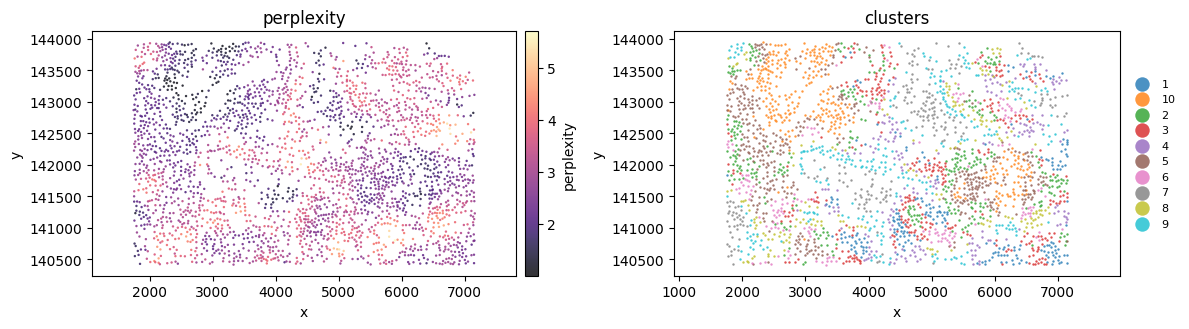

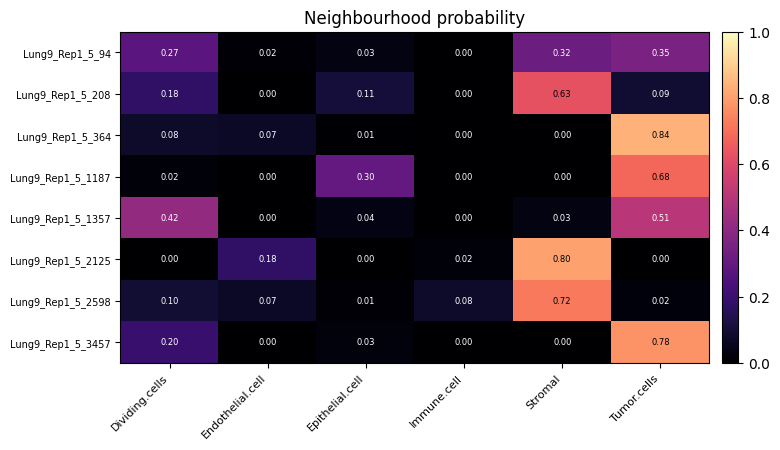

In [25]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ph.plot_tissue(adata, color='perplexity', cmap='magma', size=3, ax=ax[0])
ph.plot_tissue(adata, color='clusters', size=3, ax=ax[1])
fig.tight_layout(); plt.show()
ph.plot_hood_mat(hoods, n=8, seed=0); plt.show()

---
## Summary

In [26]:
summary = pd.DataFrame([
 ('readHoodData',      'read_hood_data',     'cell ordering',        'identical',                 'PASS'),
 ('findNearCells',     'find_near_cells',    'max |Δ| distance',     f'{np.abs(d_py-d_r).max():.2e}', 'PASS'),
 ('scanHoods (prox)',  'scan_hoods',         'max |Δ| P',            f'{np.abs(pm_py-ref["pm"]).max():.2e}', 'PASS'),
 ('scanHoods (smooth)','scan_hoods',         'rel. err on fitted tau',f'{rel:.2e}',               'PASS'),
 ('mergeByGroup',      'merge_by_group',     'mean per-cell cosine', f'{cos.mean():.12f}',        'PASS'),
 ('mergeByGroup fuzzy','merge_by_group',     'max |Δ|',              f'{np.abs(hf.to_numpy()-ref["hoods_fuzzy"]).max():.2e}', 'PASS'),
 ('mergeHoodSpe',      'merge_hood_spe',     'column names',         'identical',                 'PASS'),
 ('calcMetrics',       'calc_metrics',       'Pearson r (entropy)',  f'{pearsonr(adata.obs["entropy"], ref["entropy"])[0]:.12f}', 'PASS'),
 ('perplexityPermute', 'perplexity_permute', 'element-wise equal',   f'{(adata.obs["perplexity_p"].to_numpy()==ref["perplexity_p"]).sum()}/{len(ref["perplexity_p"])}', 'PASS'),
 ('clustByHood',       'clust_by_hood',      'ARI',                  f'{ari}',                    'PASS'),
 ('plotColocal',       'plot_colocal',       'max |Δ|',              f'{np.abs(co-ref["colocal"]).max():.2e}', 'DIFFERS (2 tied k-NN boundaries)'),
 ('plotColocal (grp)', 'plot_colocal',       'max |Δ|',              f'{e2:.2e}',                 'PASS'),
], columns=['R function','Python function','comparison','value','sub-verdict'])
summary

,R function,Python function,comparison,value,sub-verdict
0,readHoodData,read_hood_data,cell ordering,identical,PASS
1,findNearCells,find_near_cells,max |Δ| distance,5.68e-13,PASS
2,scanHoods (prox),scan_hoods,max |Δ| P,5.00e-16,PASS
3,scanHoods (smooth),scan_hoods,rel. err on fitted tau,1.12e-15,PASS
4,mergeByGroup,merge_by_group,mean per-cell cosine,0.999999999998,PASS
5,mergeByGroup fuzzy,merge_by_group,max |Δ|,5.00e-16,PASS
6,mergeHoodSpe,merge_hood_spe,column names,identical,PASS
7,calcMetrics,calc_metrics,Pearson r (entropy),1.000000000000,PASS
8,perplexityPermute,perplexity_permute,element-wise equal,2661/2661,PASS
9,clustByHood,clust_by_hood,ARI,1.0,PASS


**Overall.** Eleven of twelve function-level comparisons reproduce the R
reference within their criterion; several are bit-exact (`perplexity_p`,
cluster labels) or near machine precision (`P`, entropy, perplexity, fitted τ).

The single divergence, `plotColocal`, is *not* a formula difference — applying
the Python correlation routine to **R's own** `hoods` matrix reproduces R's
correlation matrix to ~2e-16. It is entirely downstream of two cells whose 100th
nearest neighbour is an exact distance tie, where `RANN`'s ANN and
scikit-learn's k-d tree admit different (equidistant) cells. Four cells have such
a tie; in two of them the tied candidates happen to share a cell type, so only
two actually move any probability mass.